# ML 441 Assignment 2: kNN & Decision Trees

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate, cross_val_predict
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn import set_config
from sklearn.base import clone

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Limit the size of intermediate arrays used during distance calculations.
set_config(working_memory=128)

## 1. Load data

### Reference files: `features.csv` and `attack_category_map.csv`

`features.csv` documents 41 descriptive features + the `attack_cat` target (42 named
columns total) — it does **not** list `id`, which the brief says is present and unique
per row.

`attack_category_map.csv` gives the official numeric encoding for `attack_cat`.


In [93]:
feature_ref = pd.read_csv("features.csv")
class_map = pd.read_csv("attack_category_map.csv")

print(feature_ref)
print()
print(class_map)

                 Name    Type   \
0               proto  nominal   
1               state  nominal   
2                 dur    Float   
3              sbytes  Integer   
4              dbytes  Integer   
5                sttl  Integer   
6                dttl  Integer   
7               sloss  Integer   
8               dloss  Integer   
9             service  nominal   
10              Sload    Float   
11              Dload    Float   
12              Spkts  integer   
13              Dpkts  integer   
14               swin  integer   
15               dwin  integer   
16              stcpb  integer   
17              dtcpb  integer   
18              smean  integer   
19              dmean  integer   
20        trans_depth  integer   
21  response_body_len  integer   
22               Sjit    Float   
23               Djit    Float   
24             sinpkt    Float   
25             dinpkt    Float   
26             tcprtt    Float   
27             synack    Float   
28            

In [94]:
# Nominal features per the reference doc (used later instead of hardcoding)
nominal_cols_ref = feature_ref.loc[feature_ref["Type "].str.strip().str.lower() == "nominal", "Name"].tolist()
nominal_cols_ref = [c for c in nominal_cols_ref if c != "attack_cat"]
print("Nominal features (excl. target):", nominal_cols_ref)

# Readable label mapping — use to decode class codes for plots/reports
label_to_name = dict(zip(class_map["Mapping"], class_map["Attack Category Name"]))
name_to_label = {v: k for k, v in label_to_name.items()}
print(label_to_name)

Nominal features (excl. target): ['proto', 'state', 'service']
{0: 'Normal', 1: 'Reconnaissance', 2: 'Backdoor', 3: 'DoS', 4: 'Exploits', 5: 'Analysis', 6: 'Fuzzers', 7: 'Worms', 8: 'Shellcode', 9: 'Generic'}


In [95]:
df = pd.read_csv("networkTraffic.csv", na_values=["?"])
print(df.shape)
df.head()

(257673, 44)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat
0,1,0.000011,udp,NaN,INT,2,0,496,0,90909.0902,...,1,1,2,0,0,0,1,2,0,0
1,2,0.000008,udp,NaN,INT,2,0,1762,0,125000.0003,...,1,1,2,0,0,0,1,2,0,0
2,3,0.000005,udp,NaN,INT,2,0,1068,0,200000.0051,...,1,1,3,0,0,0,1,3,0,0
3,4,0.000006,udp,NaN,INT,2,0,900,0,166666.6608,...,2,1,3,0,0,0,2,3,0,0
4,5,0.000010,udp,NaN,INT,2,0,2126,0,100000.0025,...,2,1,3,0,0,0,2,3,0,0


## 2. Exploratory / data quality checks



In [96]:
# Missing values per column
# Check each feature for missing values and display only features
# that contain at least one missing observation.
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing

service    141321
dtype: int64

Observation: service is the only feature containing missing values, with 141,321 missing observations. This represents a substantial proportion of the dataset.

Later handling: The missing values will be addressed during model-specific preprocessing. Because a large number of observations are affected, simply deleting these rows may result in considerable information loss.

In [97]:
# Check whether missing service values are associated with particular target classes.

service_missing_target = pd.crosstab(
    df["service"].isna(),
    df["attack_cat"],
    normalize="index"
) * 100

service_missing_target.index = [
    "Service present",
    "Service missing"
]

service_missing_target.round(2)

attack_cat,0,1,2,3,4,5,6,7,8,9
Service present,25.02,1.90,0.09,2.16,18.46,0.48,1.95,0.13,0.00,49.81
Service missing,45.21,8.34,1.57,9.80,16.31,1.50,15.55,0.02,1.07,0.65


Observation: Missingness in service is strongly associated with the target class, as the class distribution differs substantially between observations with and without a recorded service value.

Later handling: Missing service values should likely be preserved as a separate category rather than simply deleted or replaced with the most common service.

In [98]:
# Check the number of unique categories in each nominal feature.

for col in ["proto", "state", "service"]:
    print(col, df[col].nunique())

proto 133
state 11
service 12


Observation: proto has substantially higher cardinality than state and service, with 133 unique categories compared with 11 and 12 respectively.

Later handling: The high cardinality of proto may increase dimensionality when categorical variables are encoded, particularly for kNN, so its category frequencies should be inspected before preprocessing.

In [99]:
# Show category counts and percentages for each nominal feature.

for col in ["proto", "state", "service"]:

    distribution = pd.DataFrame({
        "Count": df[col].value_counts(dropna=False),
        "Percentage": df[col].value_counts(
            dropna=False,
            normalize=True
        ) * 100
    })

    print(f"\n{col.upper()} DISTRIBUTION")
    print("-" * 40)

    if col == "proto":
        print(distribution.head(20).round(3))
    else:
        print(distribution.round(3))


PROTO DISTRIBUTION
----------------------------------------
          Count  Percentage
proto                      
tcp      123041      47.751
udp       92701      35.976
unas      15599       6.054
arp        3846       1.493
ospf       3271       1.269
sctp       1474       0.572
any         396       0.154
gre         313       0.121
rsvp        264       0.102
ipv6        262       0.102
sun-nd      255       0.099
pim         253       0.098
mobile      253       0.098
swipe       253       0.098
sep         251       0.097
leaf-1      133       0.052
xns-idp     133       0.052
prm         133       0.052
fc          132       0.051
pup         132       0.051

STATE DISTRIBUTION
----------------------------------------
        Count  Percentage
state                    
FIN    117164      45.470
INT    116438      45.188
CON     20134       7.814
REQ      3833       1.488
RST        84       0.033
ECO        12       0.005
ACC         4       0.002
CLO         1       0.000
PA

Observation: The nominal features are highly unevenly distributed. proto is dominated by tcp and udp (about 84% combined), while state is dominated by FIN and INT (about 91% combined). service is dominated by missing values, dns, and http, with several very rare categories.

Later handling: Categorical encoding will need to account for the high cardinality of proto and the presence of rare categories. Missing service values will likely be retained as a separate category rather than removed.

In [100]:
# Check whether id is unique for every observation.

print("Number of rows:", len(df))
print("Unique id values:", df["id"].nunique())
print("Is id unique:", df["id"].is_unique)

Number of rows: 257673
Unique id values: 257673
Is id unique: True


Observation: id is unique for all 257,673 observations, confirming that it is simply an identifier rather than a meaningful predictive feature.

Later handling: id will be removed before model training.

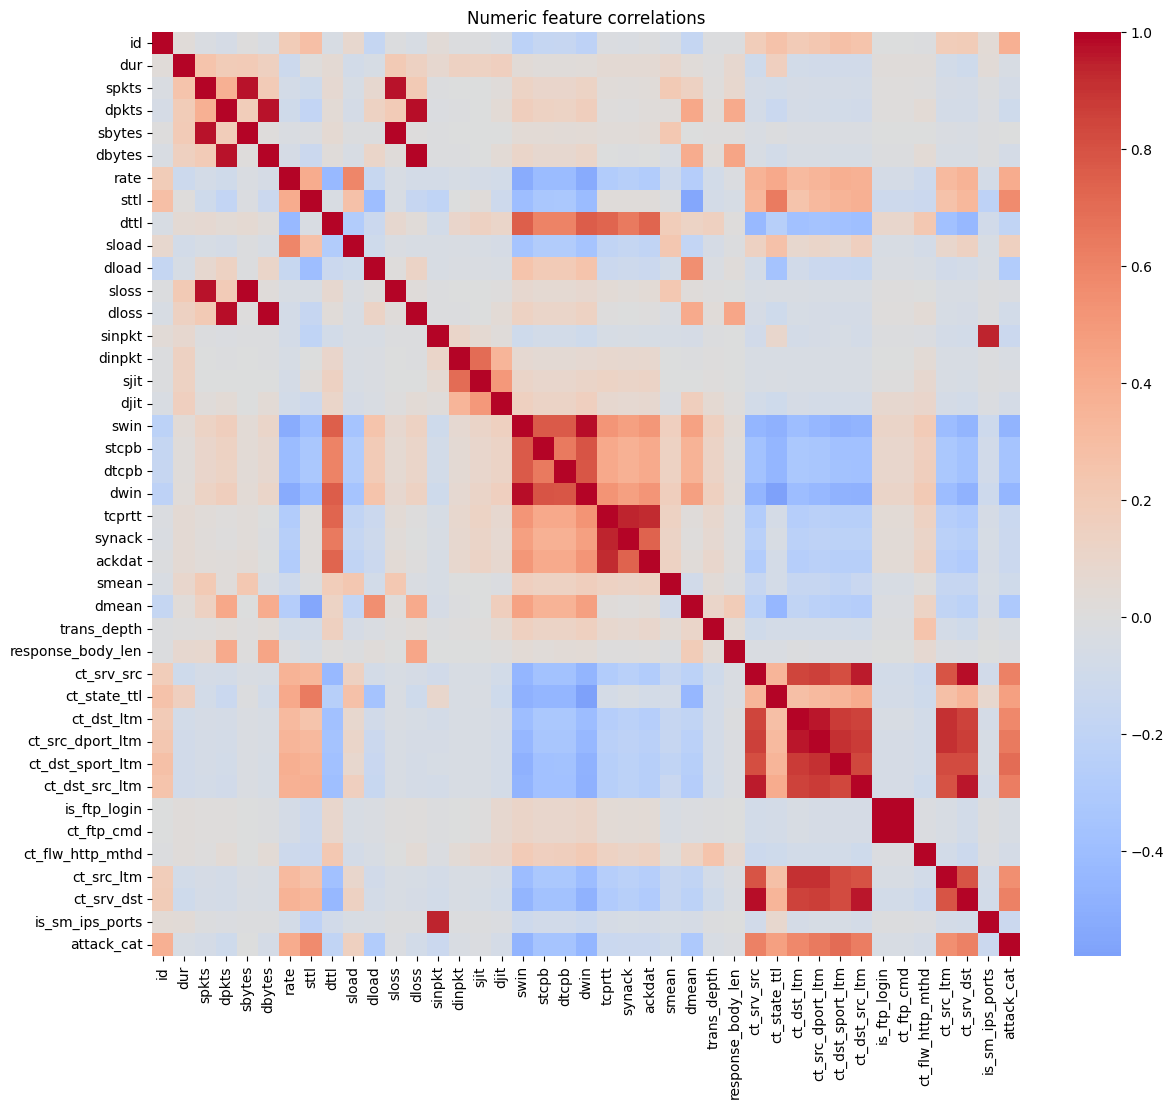

In [101]:
# Visualise correlations between numeric features to identify strongly related
# variables that may contain redundant information.

numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()
plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Numeric feature correlations")
plt.show()

Observation: Several groups of numeric features show strong positive correlations, suggesting potential redundancy between variables. The heatmap also appears to confirm the strongly correlated feature pairs highlighted in the assignment brief.

Later handling: Highly correlated features will be considered during model-specific preprocessing, particularly for kNN where redundant dimensions can influence distance calculations.

In [102]:
# Check the correlation values for the specific feature pairs highlighted
# in the assignment brief.

pairs = [
    ("sbytes", "sloss"),
    ("dbytes", "dloss"),
    ("is_ftp_login", "ct_ftp_cmd")
]

for col1, col2 in pairs:
    print(
        f"{col1} vs {col2}: "
        f"{df[col1].corr(df[col2]):.4f}"
    )

sbytes vs sloss: 0.9958
dbytes vs dloss: 0.9967
is_ftp_login vs ct_ftp_cmd: 0.9989


In [103]:
# Identify other highly correlated numeric feature pairs.
# A threshold of |r| ≥ 0.90 was used to flag very strong linear correlations for further consideration.

high_corr_pairs = []

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        value = corr.iloc[i, j]

        if abs(value) >= 0.90:
            high_corr_pairs.append(
                (
                    corr.columns[i],
                    corr.columns[j],
                    value
                )
            )

high_corr_pairs = sorted(
    high_corr_pairs,
    key=lambda x: abs(x[2]),
    reverse=True
)

for col1, col2, value in high_corr_pairs:
    print(f"{col1} vs {col2}: {value:.4f}")

is_ftp_login vs ct_ftp_cmd: 0.9989
dbytes vs dloss: 0.9967
sbytes vs sloss: 0.9958
swin vs dwin: 0.9805
dpkts vs dloss: 0.9796
ct_srv_src vs ct_srv_dst: 0.9795
dpkts vs dbytes: 0.9734
spkts vs sloss: 0.9719
spkts vs sbytes: 0.9644
ct_dst_ltm vs ct_src_dport_ltm: 0.9615
ct_dst_src_ltm vs ct_srv_dst: 0.9603
ct_srv_src vs ct_dst_src_ltm: 0.9540
tcprtt vs synack: 0.9431
sinpkt vs is_sm_ips_ports: 0.9421
tcprtt vs ackdat: 0.9202
ct_src_dport_ltm vs ct_src_ltm: 0.9094
ct_src_dport_ltm vs ct_dst_sport_ltm: 0.9083
ct_dst_ltm vs ct_src_ltm: 0.9016


Observation: Several numeric features are extremely highly correlated. The three pairs highlighted in the brief all have correlations above 0.99, and a number of additional feature pairs exceed 0.90.

Later handling: Redundant highly correlated features may need to be removed during model-specific preprocessing, particularly for kNN where duplicated information can disproportionately affect distance calculations. Correlation is expected to be less problematic for decision trees, so unnecessary feature removal will be avoided.

In [104]:
# Summarise numeric features to inspect ranges and potential extreme values.

# Select numeric predictor features only, excluding the identifier and target.

numeric_cols = (
    df.select_dtypes(include=[np.number])
    .columns
    .drop(["id", "attack_cat"])
)

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
dur,257673.0,1.246715e+00,5.974305e+00,0.0,0.000008,0.004285,6.857770e-01,5.999999e+01
spkts,257673.0,1.977714e+01,1.359472e+02,1.0,2.000000,4.000000,1.200000e+01,1.064600e+04
dpkts,257673.0,1.851470e+01,1.119860e+02,0.0,0.000000,2.000000,1.000000e+01,1.101800e+04
sbytes,257673.0,8.572952e+03,1.737739e+05,24.0,114.000000,528.000000,1.362000e+03,1.435577e+07
dbytes,257673.0,1.438729e+04,1.461993e+05,0.0,0.000000,178.000000,1.064000e+03,1.465753e+07
rate,257673.0,9.125391e+04,1.603446e+05,0.0,30.789277,2955.664893,1.250000e+05,1.000000e+06
sttl,257673.0,1.800009e+02,1.024883e+02,0.0,62.000000,254.000000,2.540000e+02,2.550000e+02
dttl,257673.0,8.475496e+01,1.127621e+02,0.0,0.000000,29.000000,2.520000e+02,2.540000e+02
sload,257673.0,7.060869e+07,1.857313e+08,0.0,12318.004880,743942.312500,8.000000e+07,5.988000e+09
dload,257673.0,6.582143e+05,2.412372e+06,0.0,0.000000,1747.441284,2.210538e+04,2.242273e+07


In [105]:
# Count potential outliers in each numeric feature using the IQR rule.

outlier_summary = []

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ).sum()

    outlier_summary.append({
        "Feature": col,
        "Outlier_Count": outliers,
        "Outlier_Percentage": outliers / len(df) * 100
    })

outlier_summary = (
    pd.DataFrame(outlier_summary)
    .sort_values("Outlier_Percentage", ascending=False)
)

outlier_summary

,Feature,Outlier_Count,Outlier_Percentage
9,dload,57556,22.336838
30,ct_src_dport_ltm,49014,19.021783
31,ct_dst_sport_ltm,48244,18.722955
32,ct_dst_src_ltm,43419,16.850427
29,ct_dst_ltm,42388,16.450307
4,dbytes,40024,15.532865
11,dloss,39660,15.391601
1,spkts,34871,13.533044
37,ct_srv_dst,34048,13.213647
24,dmean,33189,12.880278


Observation: Many numeric features contain potential high-end outliers, with several features having more than 10% of observations outside the standard IQR bounds. The descriptive statistics also show very large maximum values relative to the medians and upper quartiles, indicating strong positive skew in several variables.

Later handling: These values will not automatically be removed, as they may represent genuine network behaviour rather than errors. Their treatment will be considered separately for kNN and decision trees during preprocessing.

In [106]:
# Compare the scales of numeric predictor features using their ranges and standard deviations.

scale_summary = pd.DataFrame({
    "Min": df[numeric_cols].min(),
    "Max": df[numeric_cols].max(),
    "Mean": df[numeric_cols].mean(),
    "Std": df[numeric_cols].std()
})

scale_summary["Range"] = (
    scale_summary["Max"] - scale_summary["Min"]
)

scale_summary = scale_summary.sort_values(
    "Range",
    ascending=False
)

scale_summary

,Min,Max,Mean,Std,Range
sload,0.0,5.988000e+09,7.060869e+07,1.857313e+08,5.988000e+09
stcpb,0.0,4.294959e+09,1.006120e+09,1.367795e+09,4.294959e+09
dtcpb,0.0,4.294882e+09,1.002295e+09,1.363877e+09,4.294882e+09
dload,0.0,2.242273e+07,6.582143e+05,2.412372e+06,2.242273e+07
dbytes,0.0,1.465753e+07,1.438729e+04,1.461993e+05,1.465753e+07
sbytes,24.0,1.435577e+07,8.572952e+03,1.737739e+05,1.435575e+07
response_body_len,0.0,6.558056e+06,1.968900e+03,4.962523e+04,6.558056e+06
sjit,0.0,1.483831e+06,5.419373e+03,4.903450e+04,1.483831e+06
rate,0.0,1.000000e+06,9.125391e+04,1.603446e+05,1.000000e+06
djit,0.0,4.631992e+05,5.822515e+02,3.930153e+03,4.631992e+05


Observation: Numeric predictor features operate on substantially different scales, ranging from small bounded values to variables with values in the millions or billions.

Later handling: Scaling will be required for kNN so that large-magnitude features do not dominate the distance calculation. Scaling is not expected to be necessary for decision trees.

In [107]:
# Inspect the target class distribution to identify class imbalance.

target_col = df.columns[-1]

target_distribution = pd.DataFrame({
    "Count": df[target_col].value_counts().sort_index(),
    "Percentage": (
        df[target_col]
        .value_counts(normalize=True)
        .sort_index() * 100
    )
})

target_distribution.round(2)

,Count,Percentage
attack_cat,,
0,93000,36.09
1,13987,5.43
2,2329,0.90
3,16353,6.35
4,44525,17.28
5,2677,1.04
6,24246,9.41
7,174,0.07
8,1511,0.59


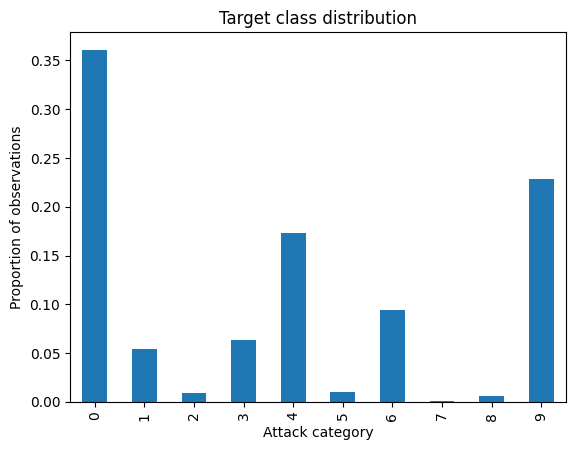

In [108]:
# Plot the proportion of observations belonging to each target class.

(
    df[target_col]
    .value_counts(normalize=True)
    .sort_index()
    .plot(kind="bar")
)

plt.title("Target class distribution")
plt.xlabel("Attack category")
plt.ylabel("Proportion of observations")
plt.show()

Observation: The target distribution is strongly imbalanced. Class 0 is the most common at 36.09%, followed by class 9 at 22.85% and class 4 at 17.28%. Several classes are rare, particularly class 7 at only 0.07% of observations.

Later handling: The imbalance will be accounted for during evaluation by using stratified cross-validation and performance metrics that consider minority-class performance rather than relying only on overall accuracy.

## 3. Preprocessing

**Important:** kNN and Decision Trees have different sensitivities (distance-based vs
axis-aligned splits), so the two pipelines will differ.

| Issue                       | kNN                                                             | Decision Tree                     | Why                                                                                                     |
| --------------------------- | --------------------------------------------------------------- | --------------------------------- | ------------------------------------------------------------------------------------------------------- |
| `id`                        | Drop                                                            | Drop                              | Unique identifier, no useful predictive information                                                     |
| Missing `service`           | Treat missing as its own category                               | Treat missing as its own category | 54.85% missing and missingness was associated with target                                               |
| `proto`, `state`, `service` | One-hot encode                                                  | One-hot encode                    | sklearn models require numeric inputs; ordinal encoding would impose artificial ordering                |
| Numeric feature scaling     | **Yes**                                                         | **No**                            | kNN uses distances; tree split decisions are unaffected by scale                                        |
| Outliers                    | Retain; scale numeric features | Retain                            | Likely genuine network behaviour; trees naturally less sensitive                                        |
| Very high correlations      | Consider removing near-redundant features                       | Generally retain                  | Correlated variables can effectively be double-counted in kNN distance; much less problematic for trees |
| Class imbalance             | Stratified CV + suitable metric                                 | Stratified CV + suitable metric   | Avoid accuracy alone because rare classes are tiny                                                      |


### 3.1 Define X, y and feature types

In [109]:
# ============================================================
# DEFINE PREDICTORS AND TARGET
# ============================================================

# Remove the target and the non-informative unique identifier.
X = df.drop(columns=["attack_cat", "id"])

# Target is already encoded as integer classes 0-9.
y = df["attack_cat"]

# Nominal categorical predictors identified in the assignment brief.
nominal_cols = ["proto", "state", "service"]

# All remaining predictors are numeric.
numeric_cols = [
    col for col in X.columns
    if col not in nominal_cols
]

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)
print("Nominal features:", nominal_cols)
print("Number of numeric features:", len(numeric_cols))

Predictor shape: (257673, 42)
Target shape: (257673,)
Nominal features: ['proto', 'state', 'service']
Number of numeric features: 39


Preprocessing decision: id is removed because it uniquely identifies each observation and contains no generalisable predictive information. The target is already represented by integer class labels, so no additional target encoding is required.

### 3.2 kNN preprocessing

In [110]:
# ============================================================
# kNN PREPROCESSOR
# ============================================================

# Numeric predictors are scaled so that variables with large
# magnitudes do not dominate the kNN distance calculation.
knn_numeric_pipeline = Pipeline([
    ("scale", MinMaxScaler())
])


# Missing service values are retained as a separate category,
# then all nominal variables are one-hot encoded.
knn_categorical_pipeline = Pipeline([
    (
        "impute",
        SimpleImputer(
            strategy="constant",
            fill_value="Missing"
        )
    ),
    (
        "encode",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])


# Apply the appropriate preprocessing to each feature type.
knn_preprocessor = ColumnTransformer([
    (
        "numeric",
        knn_numeric_pipeline,
        numeric_cols
    ),
    (
        "categorical",
        knn_categorical_pipeline,
        nominal_cols
    )
])

In [111]:
# ============================================================
# COMPLETE kNN PIPELINE
# ============================================================

knn_pipeline = Pipeline([
    ("preprocess", knn_preprocessor),
    ("model", KNeighborsClassifier())
])

knn_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default

kNN preprocessing: Numeric predictors are scaled to the range [0,1] because kNN relies on distances and the EDA showed extremely different feature scales. Nominal variables are one-hot encoded to avoid imposing an artificial ordering. Missing service values are represented by a separate "Missing" category because the EDA showed that missingness is associated with the target class.

### 3.3 Decision-tree preprocessing

In [112]:
# ============================================================
# DECISION TREE PREPROCESSOR
# ============================================================

tree_categorical_pipeline = Pipeline([
    (
        "impute",
        SimpleImputer(
            strategy="constant",
            fill_value="Missing"
        )
    ),
    (
        "encode",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])


tree_preprocessor = ColumnTransformer([
    (
        "numeric",
        "passthrough",
        numeric_cols
    ),
    (
        "categorical",
        tree_categorical_pipeline,
        nominal_cols
    )
])

In [113]:
# ============================================================
# COMPLETE DECISION TREE PIPELINE
# ============================================================

tree_pipeline = Pipeline([
    ("preprocess", tree_preprocessor),
    (
        "model",
        DecisionTreeClassifier(
            random_state=RANDOM_STATE
        )
    )
])

tree_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default

Decision-tree preprocessing: Nominal variables are one-hot encoded because sklearn's decision-tree implementation requires numeric inputs. Missing service values are retained as a separate category. Numeric predictors are not scaled because decision-tree splits depend on feature ordering and thresholds rather than distances.

### 3.4 What about the outliers?

Outliers: Potential outliers are retained because extreme network-traffic behaviour may represent genuine attacks rather than data errors. Removing or clipping these observations without evidence could discard useful predictive information. kNN remains potentially sensitive to extreme observations, while decision trees are comparatively robust to feature-based outliers.

### 3.5 And correlated features?

Correlated features: Highly correlated predictors are retained. Although redundant dimensions may influence kNN distance calculations, removing variables solely on the basis of pairwise correlation could discard useful predictive information. No additional correlation-based feature removal is therefore applied. Decision trees are also able to select between correlated predictors during splitting.

## 4. Cross-validation setup

In [114]:
# ============================================================
# CROSS-VALIDATION SETUP
# ============================================================

# Use stratified 5-fold cross-validation so that each fold
# maintains approximately the same class distribution.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Macro F1 is the primary metric because it gives equal
# importance to each class despite the class imbalance.
# Accuracy is retained as a secondary overall measure.
scoring = {
    "f1_macro": "f1_macro",
    "accuracy": "accuracy"
}

Cross-validation decision: Stratified 5-fold cross-validation is used to preserve the highly imbalanced class distribution within each fold. Five folds provide sufficiently large training and validation samples while limiting the computational cost, which is particularly important for kNN on this large dataset.

Performance metric decision: Macro F1 is used as the primary performance metric because it calculates performance for each class separately and gives all classes equal importance, preventing the dominant classes from overwhelming the evaluation. Accuracy is reported as a secondary measure of overall classification performance.

## 5. Hyperparameter tuning

In [115]:
# ============================================================
# CREATE SEPARATE TUNING AND FINAL-EVALUATION SAMPLES
# ============================================================

# Use 20% of the data for hyperparameter selection.
# The remaining 80% is kept completely separate for the
# final 5-fold cross-validation evaluation.

X_tune, X_eval, y_tune, y_eval = train_test_split(
    X,
    y,
    train_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Tuning sample:", X_tune.shape)
print("Final evaluation sample:", X_eval.shape)
print("\nTuning class proportions:")
print(y_tune.value_counts(normalize=True).sort_index().round(4))

Tuning sample: (51534, 42)
Final evaluation sample: (206139, 42)

Tuning class proportions:
attack_cat
0    0.3609
1    0.0543
2    0.0090
3    0.0635
4    0.1728
5    0.0104
6    0.0941
7    0.0007
8    0.0059
9    0.2285
Name: proportion, dtype: float64


Tuning strategy: A stratified 20% sample is used for hyperparameter selection to reduce the computational burden of kNN. The remaining 80% is reserved for the final performance evaluation and is not used during parameter selection.

In [116]:
# Use a smaller number of folds during parameter tuning
# to reduce computational cost.

tuning_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [117]:
# ============================================================
# kNN TUNING: STAGE 1
# Tune number of neighbours and voting strategy.
# ============================================================

knn_param_grid_stage1 = {
    "model__n_neighbors": [3, 5, 9, 15],
    "model__weights": ["uniform", "distance"]
}

knn_search_stage1 = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid_stage1,
    scoring="f1_macro",
    cv=tuning_cv,
    n_jobs=1,
    refit=True,
    error_score="raise"
)

knn_search_stage1.fit(X_tune, y_tune)

print("Best parameters:")
print(knn_search_stage1.best_params_)

print(
    "Best tuning Macro F1:",
    round(knn_search_stage1.best_score_, 4)
)

Best parameters:
{'model__n_neighbors': 5, 'model__weights': 'distance'}
Best tuning Macro F1: 0.4349


In [118]:
# ============================================================
# kNN TUNING: STAGE 2
# Compare Euclidean and Manhattan distance using the best
# k and weighting strategy from Stage 1.
# ============================================================

best_k = knn_search_stage1.best_params_["model__n_neighbors"]
best_weights = knn_search_stage1.best_params_["model__weights"]

knn_param_grid_stage2 = {
    "model__n_neighbors": [best_k],
    "model__weights": [best_weights],
    "model__metric": ["euclidean", "manhattan"]
}

knn_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid_stage2,
    scoring="f1_macro",
    cv=tuning_cv,
    n_jobs=1,
    refit=True
)

knn_search.fit(X_tune, y_tune)

print("Final selected kNN parameters:")
print(knn_search.best_params_)

print(
    "Tuning Macro F1:",
    round(knn_search.best_score_, 4)
)

Final selected kNN parameters:
{'model__metric': 'manhattan', 'model__n_neighbors': 5, 'model__weights': 'distance'}
Tuning Macro F1: 0.4403


Observation: The first tuning stage selected \(k=5\) with distance-weighted voting, achieving a Macro F1 of 0.4349. Using Manhattan rather than Euclidean distance further improved the tuning Macro F1 to 0.4403. The selected kNN configuration therefore uses five neighbours, distance weighting and Manhattan distance.

In [119]:
# ============================================================
# DECISION TREE HYPERPARAMETER TUNING
# ============================================================

tree_param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [5, 10, 20, None],
    "model__min_samples_leaf": [1, 5, 20]
}

tree_search = GridSearchCV(
    estimator=tree_pipeline,
    param_grid=tree_param_grid,
    scoring="f1_macro",
    cv=tuning_cv,
    n_jobs=-1,
    refit=True
)

tree_search.fit(X_tune, y_tune)

print("Best Decision Tree parameters:")
print(tree_search.best_params_)

print(
    "Best tuning Macro F1:",
    round(tree_search.best_score_, 4)
)

Best Decision Tree parameters:
{'model__criterion': 'entropy', 'model__max_depth': None, 'model__min_samples_leaf': 5}
Best tuning Macro F1: 0.5119


Observation: The best decision-tree configuration used entropy as the split criterion, no explicit maximum depth, and a minimum of five observations per leaf. This configuration achieved a mean tuning Macro F1 of 0.5119.

Interpretation: The absence of a depth limit suggests that the shallower depth constraints tested were too restrictive, while min_samples_leaf=5 provides some control over tree complexity by preventing very small terminal nodes.

## 6. Final evaluation with best configs (cross-validated)

In [120]:
# ============================================================
# FIX FINAL MODEL CONFIGURATIONS
# ============================================================

final_knn = clone(knn_pipeline)

final_knn.set_params(
    model__n_neighbors=5,
    model__weights="distance",
    model__metric="manhattan"
)


final_tree = clone(tree_pipeline)

final_tree.set_params(
    model__criterion="entropy",
    model__max_depth=None,
    model__min_samples_leaf=5
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default

In [121]:
# ============================================================
# FINAL CROSS-VALIDATION SETUP
# ============================================================

final_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [122]:
# ============================================================
# FINAL DECISION TREE EVALUATION
# ============================================================

tree_final_results = cross_validate(
    final_tree,
    X_eval,
    y_eval,
    cv=final_cv,
    scoring={
        "f1_macro": "f1_macro",
        "accuracy": "accuracy"
    },
    n_jobs=-1
)

print(
    "Decision Tree Macro F1:",
    f"{tree_final_results['test_f1_macro'].mean():.4f}",
    "+/-",
    f"{tree_final_results['test_f1_macro'].std():.4f}"
)

print(
    "Decision Tree Accuracy:",
    f"{tree_final_results['test_accuracy'].mean():.4f}",
    "+/-",
    f"{tree_final_results['test_accuracy'].std():.4f}"
)

Decision Tree Macro F1: 0.5684 +/- 0.0069
Decision Tree Accuracy: 0.8045 +/- 0.0012


Observation: The tuned decision tree achieved a mean Macro F1 of 0.5684 and mean accuracy of 0.8045 across five stratified folds. The low standard deviations indicate that performance was stable across the folds.
Interpretation: Accuracy is relatively high, but Macro F1 remains the more informative primary measure because the target classes are strongly imbalanced.

In [123]:
# ============================================================
# FINAL kNN EVALUATION
# ============================================================

knn_final_results = cross_validate(
    final_knn,
    X_eval,
    y_eval,
    cv=final_cv,
    scoring={
        "f1_macro": "f1_macro",
        "accuracy": "accuracy"
    },
    n_jobs=1
)

print(
    "kNN Macro F1:",
    f"{knn_final_results['test_f1_macro'].mean():.4f}",
    "+/-",
    f"{knn_final_results['test_f1_macro'].std():.4f}"
)

print(
    "kNN Accuracy:",
    f"{knn_final_results['test_accuracy'].mean():.4f}",
    "+/-",
    f"{knn_final_results['test_accuracy'].std():.4f}"
)

kNN Macro F1: 0.4799 +/- 0.0081
kNN Accuracy: 0.7795 +/- 0.0013


Observation: The tuned kNN achieved a mean Macro F1 of 0.4799 and mean accuracy of 0.7795 across five stratified folds. Performance was stable across folds, as indicated by the small standard deviations.

Comparison: The decision tree outperformed kNN on both Macro F1 and accuracy. The larger improvement in Macro F1 suggests that the decision tree performs better across the full set of attack classes, including the less frequent classes.

In [124]:
# ============================================================
# DECISION TREE OUT-OF-FOLD PREDICTIONS
# ============================================================

tree_oof_pred = cross_val_predict(
    final_tree,
    X_eval,
    y_eval,
    cv=final_cv,
    n_jobs=-1
)

print(
    classification_report(
        y_eval,
        tree_oof_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9069    0.9169    0.9119     74400
           1     0.8908    0.7605    0.8205     11190
           2     0.2768    0.0789    0.1228      1863
           3     0.3190    0.3352    0.3269     13082
           4     0.6406    0.7407    0.6870     35620
           5     0.3977    0.0952    0.1537      2142
           6     0.6284    0.5673    0.5963     19397
           7     0.5688    0.4460    0.5000       139
           8     0.5861    0.5715    0.5787      1209
           9     0.9927    0.9819    0.9873     47097

    accuracy                         0.8045    206139
   macro avg     0.6208    0.5494    0.5685    206139
weighted avg     0.8030    0.8045    0.8012    206139



Observation: Decision-tree performance varies considerably across classes. Classes 0, 1, and 9 are classified very well, while classes 2, 3, and 5 are substantially more difficult, particularly due to low recall. Despite its very small support, class 7 achieves an F1 score of 0.5000.

Interpretation: The difference between the weighted F1 (0.8012) and Macro F1 (0.5685) reflects the class imbalance: strong performance on the common classes masks weaker performance on several minority classes.

In [125]:
# ============================================================
# kNN OUT-OF-FOLD PREDICTIONS
# ============================================================

knn_oof_pred = cross_val_predict(
    final_knn,
    X_eval,
    y_eval,
    cv=final_cv,
    n_jobs=1
)

print(
    classification_report(
        y_eval,
        knn_oof_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.8802    0.9177    0.8985     74400
           1     0.6111    0.6740    0.6410     11190
           2     0.0512    0.0247    0.0333      1863
           3     0.3181    0.3593    0.3374     13082
           4     0.6472    0.6847    0.6654     35620
           5     0.5023    0.1008    0.1680      2142
           6     0.5902    0.4729    0.5251     19397
           7     0.3208    0.1223    0.1771       139
           8     0.5252    0.2845    0.3691      1209
           9     0.9954    0.9763    0.9857     47097

    accuracy                         0.7795    206139
   macro avg     0.5442    0.4617    0.4801    206139
weighted avg     0.7748    0.7795    0.7745    206139



Observation: kNN performs strongly on the dominant classes, particularly classes 0 and 9, but performs poorly on several minority classes. The decision tree achieves higher F1 scores for eight of the ten classes, with particularly large improvements for classes 1, 7, and 8.

Interpretation: kNN’s lower Macro F1 is largely driven by weak performance on minority classes. This supports the decision tree as the better overall classifier for this imbalanced multiclass problem.

### 6.4 Confusion Matrices

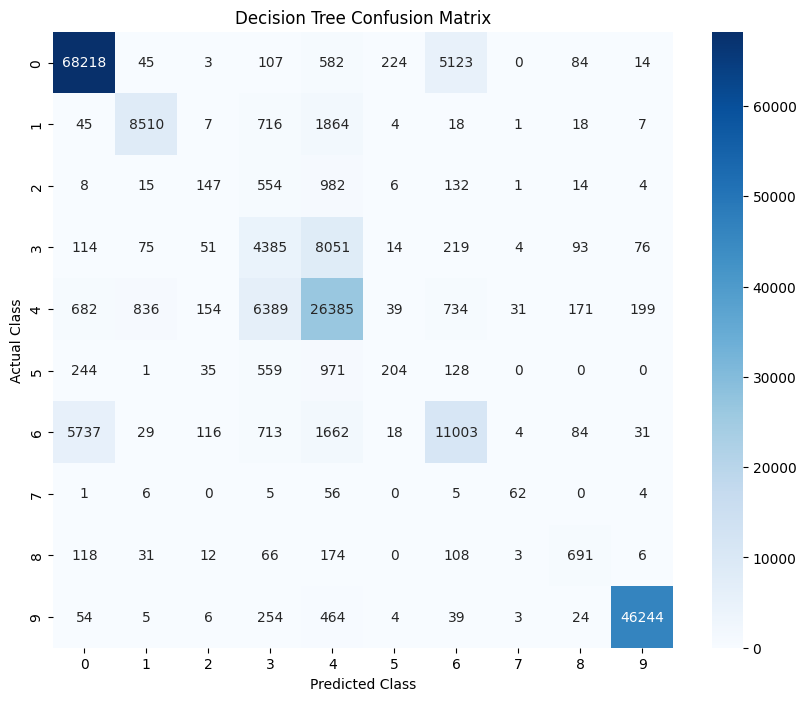

In [126]:
# ============================================================
# DECISION TREE CONFUSION MATRIX
# ============================================================

tree_cm = confusion_matrix(
    y_eval,
    tree_oof_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    tree_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

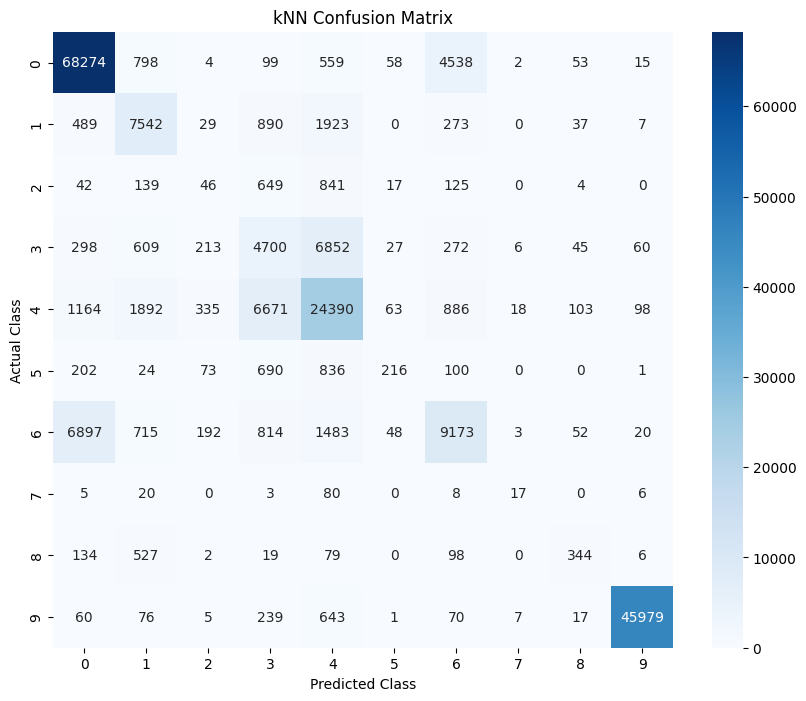

In [127]:
# ============================================================
# kNN CONFUSION MATRIX
# ============================================================

knn_cm = confusion_matrix(
    y_eval,
    knn_oof_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    knn_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("kNN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

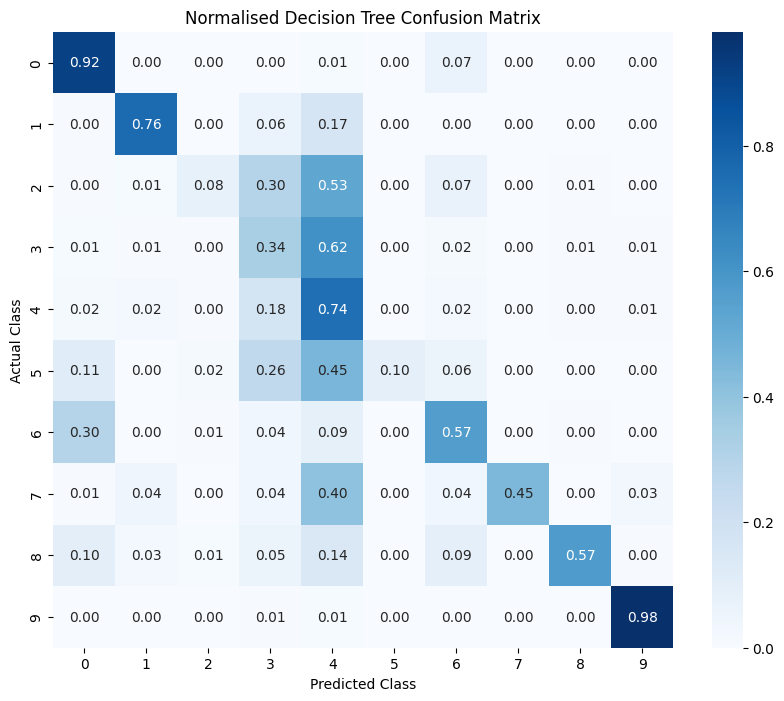

In [128]:
# ============================================================
# NORMALISED DECISION TREE CONFUSION MATRIX
# ============================================================

tree_cm_norm = confusion_matrix(
    y_eval,
    tree_oof_pred,
    normalize="true"
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    tree_cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Normalised Decision Tree Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

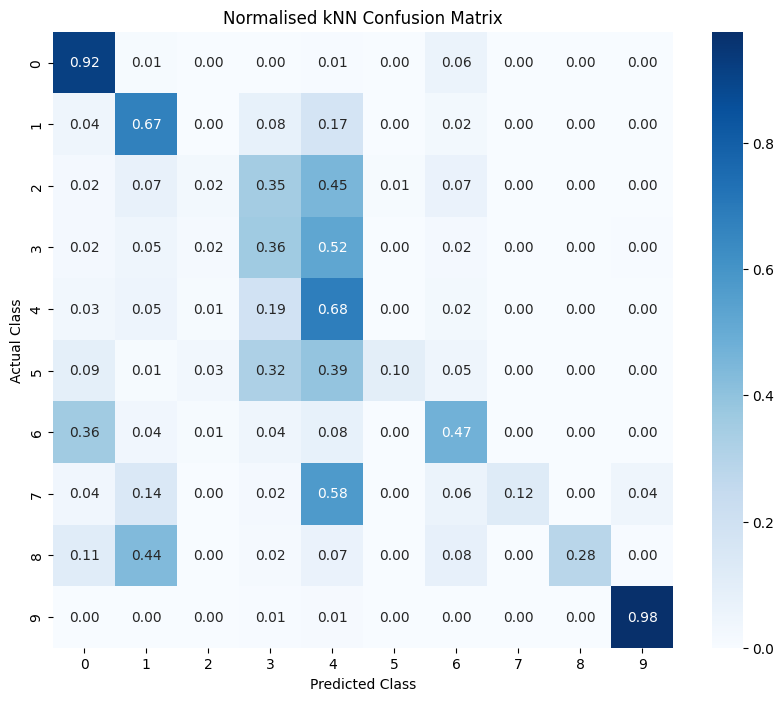

In [129]:
# ============================================================
# NORMALISED kNN CONFUSION MATRIX
# ============================================================

knn_cm_norm = confusion_matrix(
    y_eval,
    knn_oof_pred,
    normalize="true"
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    knn_cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Normalised kNN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

Observation: Both classifiers perform strongly on the dominant classes 0 and 9, but struggle with several minority classes. Misclassification is particularly concentrated toward class 4. The decision tree generally achieves higher recall for minority classes, most notably classes 1, 7, and 8, which helps explain its higher Macro F1 score.

In [130]:
# ============================================================
# FINAL MODEL PERFORMANCE SUMMARY
# ============================================================

final_results = pd.DataFrame({
    "Model": [
        "kNN",
        "Decision Tree"
    ],
    "Macro F1 Mean": [
        knn_final_results["test_f1_macro"].mean(),
        tree_final_results["test_f1_macro"].mean()
    ],
    "Macro F1 SD": [
        knn_final_results["test_f1_macro"].std(),
        tree_final_results["test_f1_macro"].std()
    ],
    "Accuracy Mean": [
        knn_final_results["test_accuracy"].mean(),
        tree_final_results["test_accuracy"].mean()
    ],
    "Accuracy SD": [
        knn_final_results["test_accuracy"].std(),
        tree_final_results["test_accuracy"].std()
    ]
})

final_results.round(4)

,Model,Macro F1 Mean,Macro F1 SD,Accuracy Mean,Accuracy SD
0,kNN,0.4799,0.0081,0.7795,0.0013
1,Decision Tree,0.5684,0.0069,0.8045,0.0012


## 7. Conclusion
At this stage, the tuned decision tree performed better than the kNN model on the final evaluation sample, achieving a higher Macro F1 score. This suggests that the decision tree is currently better able to distinguish between the different attack categories, particularly given the class imbalance in the dataset.

The kNN model showed weaker performance across several of the less common classes, while the decision tree provided a better overall balance across categories. These results may still change as further model adjustments and evaluation are completed.
